<a href="https://colab.research.google.com/github/honmin21/Data_Science_Tasks/blob/main/Linear_Regression_Taxi_tip_Pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import  LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
df = pd.read_csv("/content/taxi_trip_pricing (1).csv")

#**Data Cleaning**

In [4]:
missing_values = df.isnull().sum()
print(missing_values)

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


 imputing missing numerical values with their respective medians. I will start by identifying the numerical columns specified in the instructions and then calculate the median for each of them. After that, I will use the calculated medians to fill the missing values in those columns.



In [8]:
numerical_cols = ['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price']

for col in numerical_cols:
    mean_val = df[col].mean()
    df[col].fillna(mean_val, inplace=True)

missing_values_after_imputation = df.isnull().sum()
print(missing_values_after_imputation)

Trip_Distance_km          0
Time_of_Day              50
Day_of_Week              50
Passenger_Count           0
Traffic_Conditions       50
Weather                  50
Base_Fare                 0
Per_Km_Rate               0
Per_Minute_Rate           0
Trip_Duration_Minutes     0
Trip_Price                0
dtype: int64


/tmp/ipykernel_611/3495661377.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mean_val, inplace=True)


**Reasoning**:
The previous code used `mean()` instead of `median()` for imputation, and received a `FutureWarning` about `inplace=True`. I will correct this by calculating the median for each numerical column and assigning the filled column back to the DataFrame to avoid `SettingWithCopyWarning`.



In [9]:
numerical_cols = ['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price']

for col in numerical_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

missing_values_after_imputation = df.isnull().sum()
print(missing_values_after_imputation)

Trip_Distance_km          0
Time_of_Day              50
Day_of_Week              50
Passenger_Count           0
Traffic_Conditions       50
Weather                  50
Base_Fare                 0
Per_Km_Rate               0
Per_Minute_Rate           0
Trip_Duration_Minutes     0
Trip_Price                0
dtype: int64


 need to identify the categorical columns with missing values and then impute them with their respective mode values.


In [11]:
categorical_cols = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']

for col in categorical_cols:
    mode_val = df[col].mode()[0]  # Get the first mode in case of ties
    df[col].fillna(mode_val, inplace=True)

missing_values_after_categorical_imputation = df.isnull().sum()
print(missing_values_after_categorical_imputation)

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64



convert the `Passenger_Count` column to an integer type.



In [12]:
df['Passenger_Count'] = df['Passenger_Count'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       1000 non-null   float64
 1   Time_of_Day            1000 non-null   object 
 2   Day_of_Week            1000 non-null   object 
 3   Passenger_Count        1000 non-null   int64  
 4   Traffic_Conditions     1000 non-null   object 
 5   Weather                1000 non-null   object 
 6   Base_Fare              1000 non-null   float64
 7   Per_Km_Rate            1000 non-null   float64
 8   Per_Minute_Rate        1000 non-null   float64
 9   Trip_Duration_Minutes  1000 non-null   float64
 10  Trip_Price             1000 non-null   float64
dtypes: float64(6), int64(1), object(4)
memory usage: 86.1+ KB


In [14]:
categorical_cols = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']

for col in categorical_cols:
    df[col] = df[col].astype('category')

print("Data types after converting categorical columns:")
df.info()

Data types after converting categorical columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Trip_Distance_km       1000 non-null   float64 
 1   Time_of_Day            1000 non-null   category
 2   Day_of_Week            1000 non-null   category
 3   Passenger_Count        1000 non-null   int64   
 4   Traffic_Conditions     1000 non-null   category
 5   Weather                1000 non-null   category
 6   Base_Fare              1000 non-null   float64 
 7   Per_Km_Rate            1000 non-null   float64 
 8   Per_Minute_Rate        1000 non-null   float64 
 9   Trip_Duration_Minutes  1000 non-null   float64 
 10  Trip_Price             1000 non-null   float64 
dtypes: category(4), float64(6), int64(1)
memory usage: 59.3 KB


In [15]:
df.info()
print("\nMissing values after all imputations:")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Trip_Distance_km       1000 non-null   float64 
 1   Time_of_Day            1000 non-null   category
 2   Day_of_Week            1000 non-null   category
 3   Passenger_Count        1000 non-null   int64   
 4   Traffic_Conditions     1000 non-null   category
 5   Weather                1000 non-null   category
 6   Base_Fare              1000 non-null   float64 
 7   Per_Km_Rate            1000 non-null   float64 
 8   Per_Minute_Rate        1000 non-null   float64 
 9   Trip_Duration_Minutes  1000 non-null   float64 
 10  Trip_Price             1000 non-null   float64 
dtypes: category(4), float64(6), int64(1)
memory usage: 59.3 KB

Missing values after all imputations:


,0
Trip_Distance_km,0
Time_of_Day,0
Day_of_Week,0
Passenger_Count,0
Traffic_Conditions,0
Weather,0
Base_Fare,0
Per_Km_Rate,0
Per_Minute_Rate,0
Trip_Duration_Minutes,0


**LABEL ENCODING**

In [17]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoders = {}

categorical_cols_for_encoding = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']

for col in categorical_cols_for_encoding:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store the encoder for future use if needed

print("DataFrame after Label Encoding:")
display(df.head())

DataFrame after Label Encoding:


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,2,0,3,1,0,3.56,0.80,0.32,53.82,36.2624
1,47.59,0,0,1,0,0,3.52,0.62,0.43,40.57,50.0745
2,36.87,1,1,1,0,0,2.70,1.21,0.15,37.27,52.9032
3,30.33,1,0,4,1,0,3.48,0.51,0.15,116.81,36.4698
4,25.83,1,0,3,0,0,2.93,0.63,0.32,22.64,15.6180


**LINEAR REGRESSION**


To prepare for linear regression, define the features (X) and the target variable (y). Based on the dataset, `Trip_Price` is the target variable, and all other numerical and encoded categorical columns will serve as features.


In [18]:
# Define features (X) and target (y)
X = df.drop('Trip_Price', axis=1)
y = df['Trip_Price']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)


Features (X) shape: (1000, 10)
Target (y) shape: (1000,)


**Reasoning**:
To evaluate the model's performance on unseen data,  split the dataset into training and testing sets. A common split is 70% for training and 30% for testing. `random_state` will be set for reproducibility.


In [22]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (800, 10)
X_test shape: (200, 10)
y_train shape: (800,)
y_test shape: (200,)


**Reasoning**:
Now that the data is split,  initialize a `LinearRegression` model and train it using the training data (`X_train` and `y_train`). After training,  make predictions on the test set (`X_test`) to evaluate the model's performance.


In [23]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Model training complete. Predictions made on the test set.")


Model training complete. Predictions made on the test set.


**Reasoning**:
To assess the performance of the trained linear regression model, calculate several key evaluation metrics: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared. These metrics will provide a comprehensive understanding of how well the model predicts `Trip_Price`.


Mean Squared Error (MSE): 191.06
Root Mean Squared Error (RMSE): 13.82
Mean Absolute Error (MAE): 9.84
R-squared (R2): 0.77


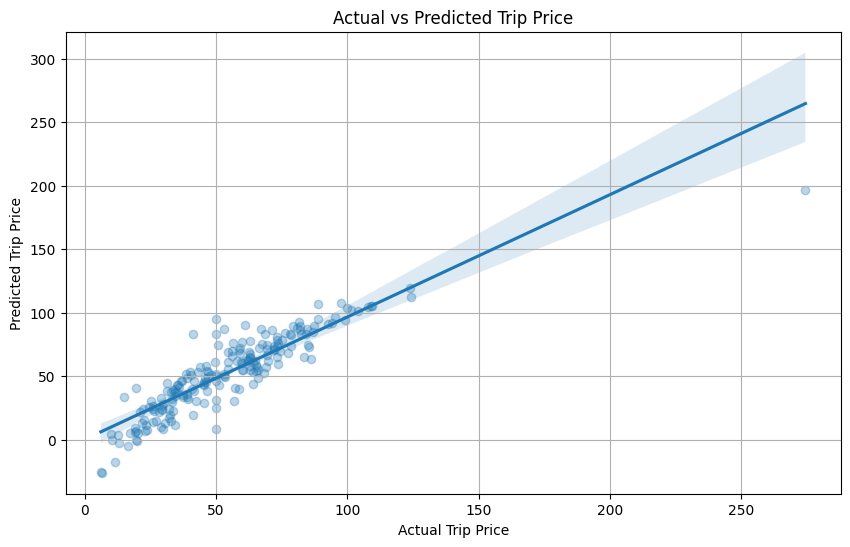

In [24]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Optionally, visualize predictions vs actual values
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3})
plt.xlabel('Actual Trip Price')
plt.ylabel('Predicted Trip Price')
plt.title('Actual vs Predicted Trip Price')
plt.grid(True)
plt.show()
